In [292]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
from scipy.signal import butter, sosfiltfilt
import scipy

if __package__ in {None, ""}:
    sys.path.insert(0, str(Path("../").resolve()))

from backend.mag_to_travel_model_core import MagToTravelChunk, MagToTravelModelCore
#from backend.rear_mag_model import RearMagModel

In [293]:
#log_filename = "log146_reartest_sag"
log_filename = "log153_rear"

In [294]:
out_dir = f"../backend/run_artifacts/{log_filename}/cache/"
ws_file = out_dir + "/all.npz"
ws = np.load(ws_file)
print([str(key) for key in ws.keys()])
accel_idx = "2"
a = ws[f"accel/lpf/lis{accel_idx}__x"]
a1 = ws[f"accel/lpf/lis1__x"]
b_raw = ws["mag/lpf__x"]
b2_raw = ws["mag_lis/lpf__x"]
b_diff = ws["mag_diff/lpf__x"]
b_proj = ws["mag/proj/lpf__x"][:, 0]
gyro = ws[f"gyro/lpf/gyro{accel_idx}__x"]
t = ws[f"accel/lpf/lis{accel_idx}__t"]
travel = ws["travel__x"][:, 0]

v_gt = np.gradient(travel, t, edge_order = 2)
a_gt = np.gradient(v_gt, t, edge_order = 2) / 1000.0

['__log_config_hash', 'accel/lis1__t', 'accel/lis1__x', 'gyro/gyro1__t', 'gyro/gyro1__x', 'accel/lis2__t', 'accel/lis2__x', 'gyro/gyro2__t', 'gyro/gyro2__x', 'mag__t', 'mag__x', 'mag_lis__t', 'mag_lis__x', 'angle__t', 'angle__x', 'angle/bad_mask__t', 'angle/bad_mask__x', 'gyro/lpf/gyro1__t', 'gyro/lpf/gyro1__x', 'gyro/lpf/gyro2__t', 'gyro/lpf/gyro2__x', 'accel/lpf/lis1__t', 'accel/lpf/lis1__x', 'accel/lpf/lis2__t', 'accel/lpf/lis2__x', 'accel/lphp/lis2__t', 'accel/lphp/lis2__x', 'accel_trav_vec', 'accel/lphp/proj__t', 'accel/lphp/proj__x', 'angle/lpf__t', 'angle/lpf__x', 'travel__t', 'travel__x', 'boring_mask', 'mag/lpf__t', 'mag/lpf__x', 'mag_lis/lpf__t', 'mag_lis/lpf__x', 'mag_diff__t', 'mag_diff__x', 'mag_diff/lpf__t', 'mag_diff/lpf__x', 'mag/proj__t', 'mag/proj__x', 'mag/proj/lpf__t', 'mag/proj/lpf__x', 'mag_zv_points', 'travel/mag_model__t', 'travel/mag_model__x', 'travel/mag_model/adj__t', 'travel/mag_model/adj__x', 'fusion_scatter_points', 'mag_model_coeffs', 'travel/solved__t',

In [295]:
# Get mag norm and polar coords
def get_polar(vec):
    mag =  np.linalg.norm(vec, axis=1)
    normed = (vec.T / mag).T
    theta = np.degrees(np.atan2(normed[:, 1], normed[:, 0]))
    phi = np.degrees(np.arcsin(normed[:, 2]))
    return mag, theta, phi

b1_mag, b1_theta, b1_phi = get_polar(b_raw)
b2_mag, b2_theta, b2_phi = get_polar(b2_raw)

# MMC Y is -LIS X
# MMC X is LIS Y
# lis_rot = [[0, 1, 0],
#            [-1, 0, 0],
#            [0, 0, 1]]
lis_rot = [[1, 0, 0],
           [0, 1, 0],
           [0, 0, 1]]
lis_rot = np.asarray(lis_rot)

b2_rot = (lis_rot @ b2_raw.T).T
b_corr = b_diff #b_raw - b2_rot
b_corr_mag = np.linalg.norm(b_corr, axis=1)

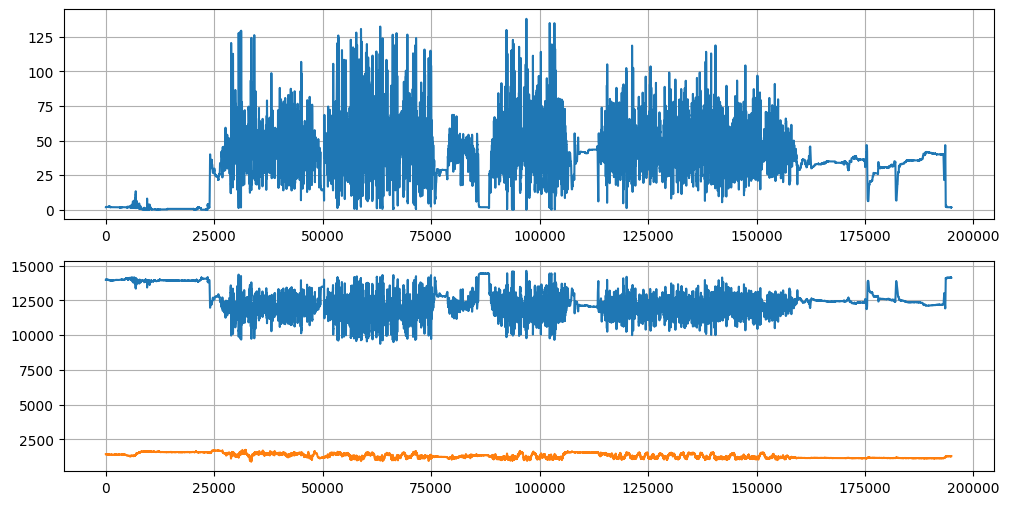

In [296]:
# Plot travel, mag norm
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(travel)
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(b1_mag)
plt.plot(b2_mag)
plt.grid()

-0.981677689451293 -0.9836109988031311
-0.9743610974080119 -0.9704681186176289
-0.974502224617659 -0.9703693820752793


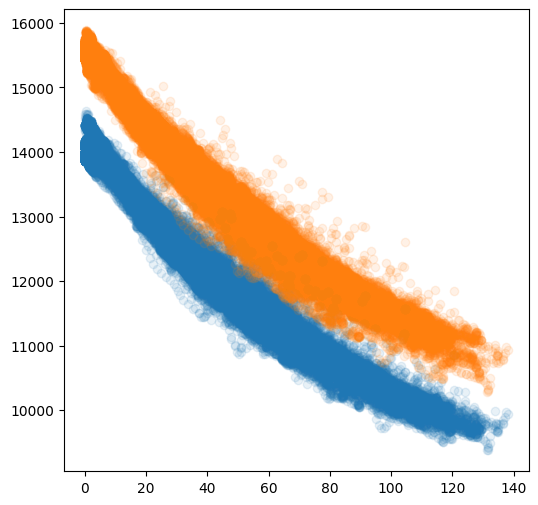

In [297]:
# Plot angle vs mag norm
plt.figure(figsize=(6, 6))
plt.scatter(travel, b1_mag, alpha=0.1)
plt.scatter(travel, b_corr_mag, alpha=0.1)
corr = scipy.stats.pearsonr(travel, b1_mag)
spearman = scipy.stats.spearmanr(travel, b1_mag)
print(corr[0], spearman.correlation)
corr = scipy.stats.pearsonr(travel, b_corr_mag)
spearman = scipy.stats.spearmanr(travel, b_corr_mag)
print(corr[0], spearman.correlation)
corr = scipy.stats.pearsonr(travel, b_proj)
spearman = scipy.stats.spearmanr(travel, b_proj)
print(corr[0], spearman.correlation)

In [298]:
roi = slice(0, -1)
roi = slice(130000, 135000)

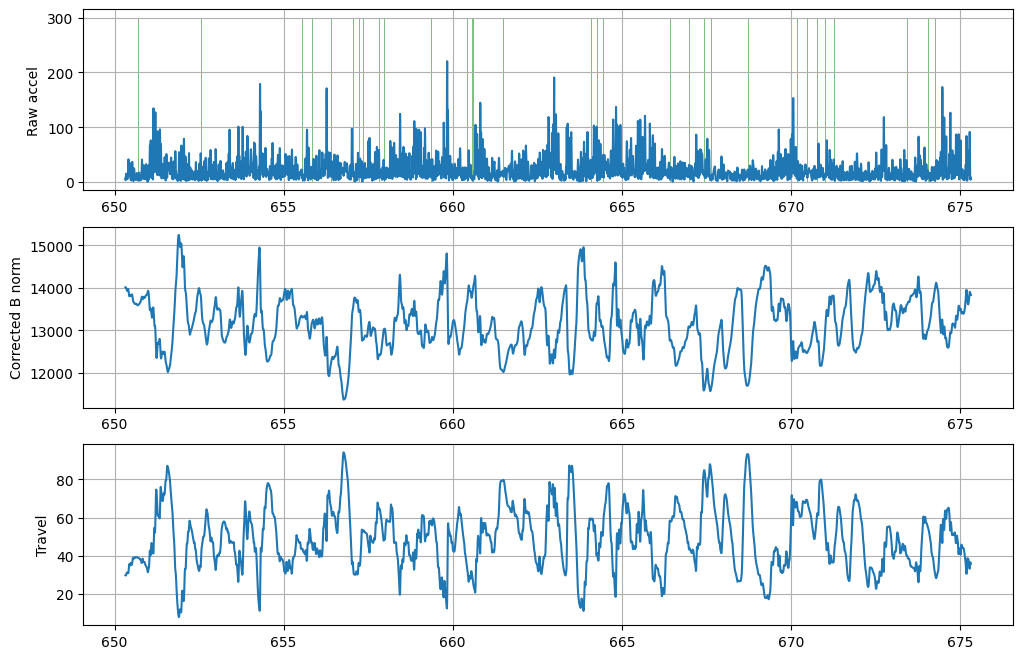

In [299]:
# Plot accelerometer, travel, mag data

a_norm = np.linalg.norm(a, axis=1)
near_grav = (a_norm < 11.8) & (a_norm > 7.8)

plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.ylabel("Raw accel")
plt.plot(t[roi], a_norm[roi])
ax = plt.gca()
ax.fill_between(t[roi], 300, where=near_grav[roi], facecolor='green', alpha=.5)
plt.grid()
plt.subplot(3, 1, 2)
plt.ylabel("Corrected B norm")
plt.plot(t[roi], b_corr_mag[roi])
plt.grid()
plt.subplot(3, 1, 3)
plt.ylabel("Travel")
plt.plot(t[roi], travel[roi])
plt.grid()


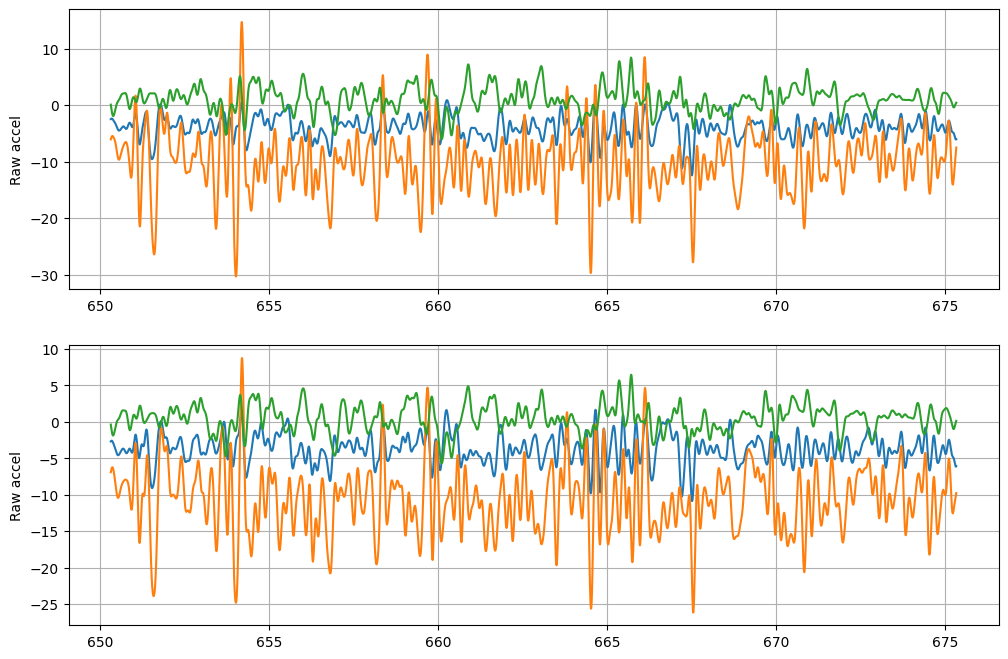

In [300]:
# Plot individual accelerometer axes
lp_fc_hz=5
sos_lp = butter(N=4, Wn=lp_fc_hz, btype="low", fs=200, output="sos")
a_lp = sosfiltfilt(sos_lp, a, axis=0)
a1_lp = sosfiltfilt(sos_lp, a1, axis=0)
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.ylabel("Raw accel")
plt.plot(t[roi], a_lp[roi])
plt.grid()
plt.subplot(2, 1, 2)
plt.ylabel("Raw accel")
plt.plot(t[roi], a1_lp[roi])
plt.grid()

Mean accel dir [-3.87020862 -9.22505653  1.52417988]
Travel-correlated accel axis: [-0.34705234 -0.93601719  0.05853619]
Main accel axis: [-0.29617601 -0.95383726  0.04974191]
Accel MA, RMS: 6.958399696580377 17.180446354134453
Accel error MAE, RMSE: 9.299788964639395 17.39653407770283


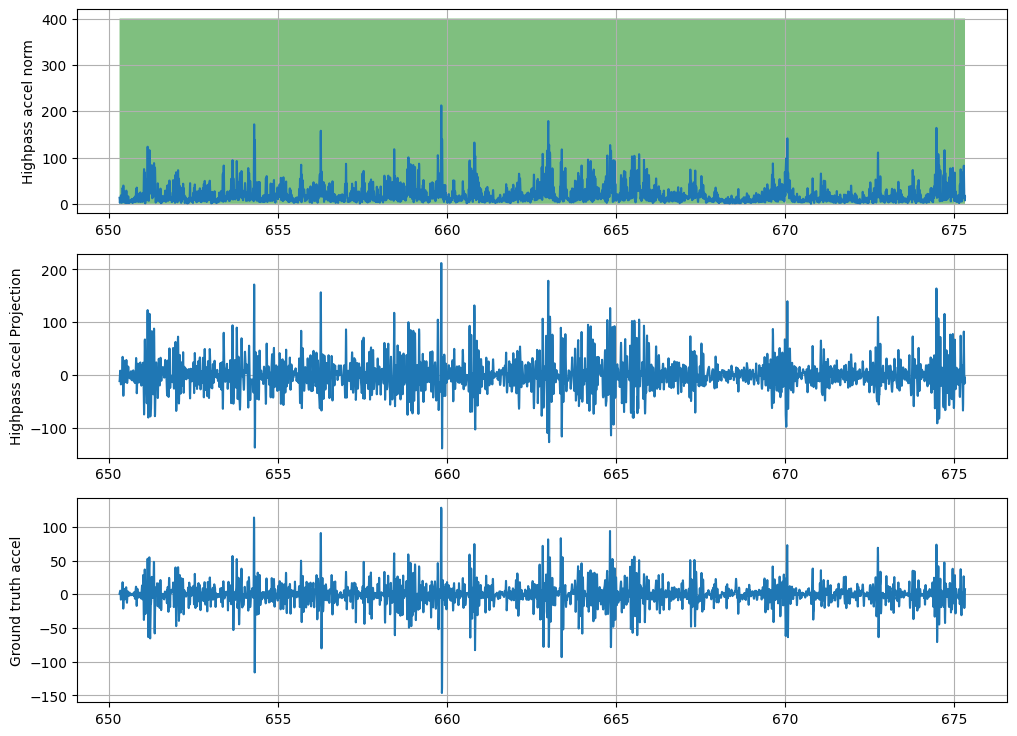

In [301]:
# Highpass accel and project
hp_fc_hz=2
sos_hp = butter(N=2, Wn=hp_fc_hz, btype="high", fs=200, output="sos")
a_hp = sosfiltfilt(sos_hp, a, axis=0)
a_hp_norm, a_hp_theta, a_hp_phi = get_polar(a_hp)

mask = (a_hp_norm > 10)
# dilate mask
mask = np.convolve(mask, np.ones(200), mode="same") > 0

mean_accel_dir = np.mean(a, axis=0)
print("Mean accel dir", mean_accel_dir)
gt_accel_axis = np.mean(a_hp * a_gt[:, np.newaxis], axis=0)
gt_accel_axis /= np.linalg.norm(gt_accel_axis)
print("Travel-correlated accel axis:", gt_accel_axis)
# Find main axis of acceleration
a_hp_m = a_hp[mask]
accel_axis = np.mean(a_hp_m[a_hp_m[:, 1] < 0], axis=0)
accel_axis /= np.linalg.norm(accel_axis)
print("Main accel axis:", accel_axis)
a_hp_proj = a_hp @ accel_axis
a_proj = a @ accel_axis

acc_err = a_hp_proj - a_gt
print("Accel MA, RMS:", np.mean(np.abs(a_gt)), np.sqrt(np.mean(a_gt**2)))
print("Accel error MAE, RMSE:", np.mean(np.abs(acc_err)), np.sqrt(np.mean(acc_err**2)))

plt.figure(figsize=(12, 9))
plt.subplot(3, 1, 1)
plt.plot(t[roi], a_hp_norm[roi])
plt.ylabel("Highpass accel norm")
plt.fill_between(t[roi], 400, where=mask[roi], facecolor='green', alpha=.5)
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(t[roi], a_hp_proj[roi])
plt.ylabel("Highpass accel Projection")
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(t[roi], a_gt[roi])
plt.ylabel("Ground truth accel")
plt.grid()

Bin points: [3671, 19418, 49851, 11990, 16331]
Bin centers: [11638.01764487 12547.25367804 13456.48971121 14365.72574438
 15274.96177755]


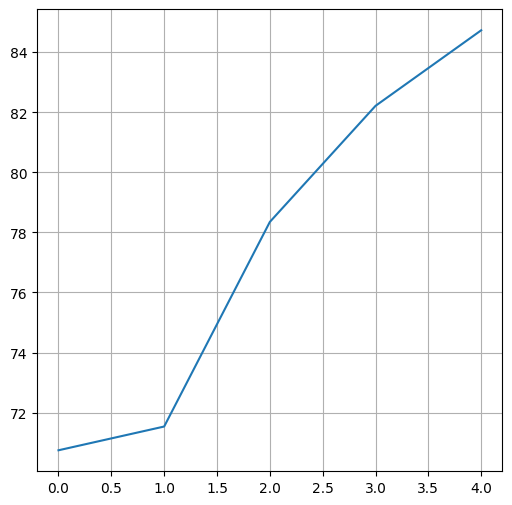

In [ ]:
# Plot accel direction as a function of travel or mag
hist_x = b_proj
n_bins = 5
hist_min = np.percentile(hist_x, 0.5)
hist_max = np.percentile(hist_x, 99.5)
bin_size = (hist_max - hist_min) / n_bins

bin_mean_theta = []
bin_pts = []
for i in range(n_bins):
    bin_min = hist_min + (i * bin_size)
    bin_max = bin_min + bin_size
    bin_mask = (bin_min <= hist_x) & (hist_x < bin_max)
    bin_mask &= a_hp[:, 1] > 0
    # bin_a_mean = np.mean(a_hp[bin_mask], axis=0)
    # _, bin_theta_mean, _ = get_polar(bin_a_mean[np.newaxis])
    _, bin_theta, _ = get_polar(a_hp[bin_mask])
    bin_theta_mean = np.median(bin_theta)
    bin_mean_theta.append(bin_theta_mean)
    bin_pts.append(int(np.sum(bin_mask)))

print("Bin points:", bin_pts)
print("Bin centers:", hist_min + (np.arange(n_bins) + 0.5) * bin_size)
print("Bin mean thetas:", bin_mean_theta)
plt.figure(figsize=(6, 6))
plt.plot(range(n_bins), bin_mean_theta)
plt.grid()


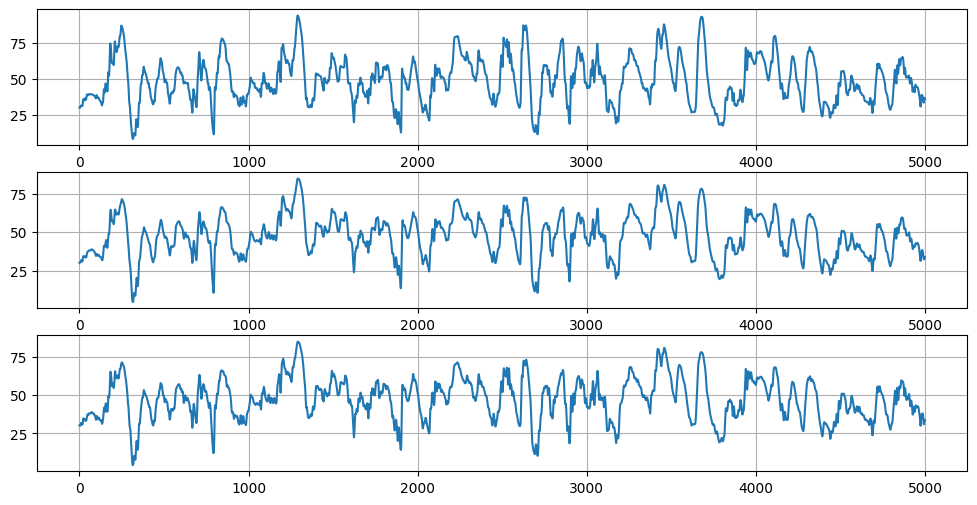

In [303]:
# Plot pipeline outputs
travel_mag_adj = ws["travel/mag_model/adj__x"][:, 0]
travel_solved = ws["travel/solved__x"][:, 0]
travel_mag_adj -= np.mean(travel_mag_adj - travel)
travel_solved -= np.mean(travel_solved - travel)

plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(travel[roi])
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(travel_mag_adj[roi])
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(travel_solved[roi])
plt.grid()

1.3439360193667725e-15
1.79191469248903e-15


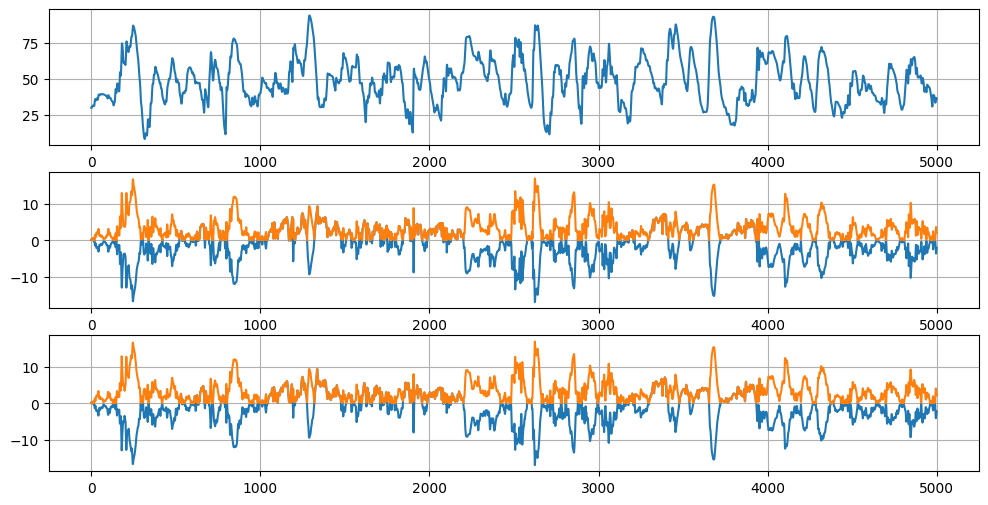

In [304]:
# Plot pipeline output abs errors
travel_mag_err = travel_mag_adj - travel
travel_solved_err = travel_solved - travel
print(np.mean(travel_mag_err))
print(np.mean(travel_solved_err))

plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(travel[roi])
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(travel_mag_err[roi])
plt.plot(np.abs(travel_mag_err[roi]))
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(travel_solved_err[roi])
plt.plot(np.abs(travel_solved_err[roi]))
plt.grid()

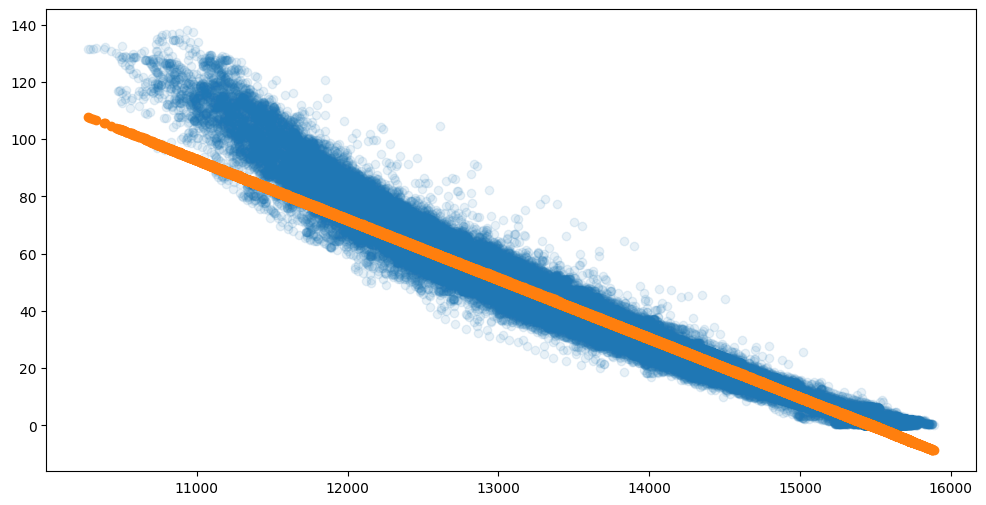

In [305]:
# Scatter mag model errors
plt.figure(figsize=(12, 6))
plt.scatter(b_corr_mag, travel, alpha=0.1)
plt.scatter(b_corr_mag, travel_mag_adj)
#plt.scatter(b_corr_mag, travel_solved)

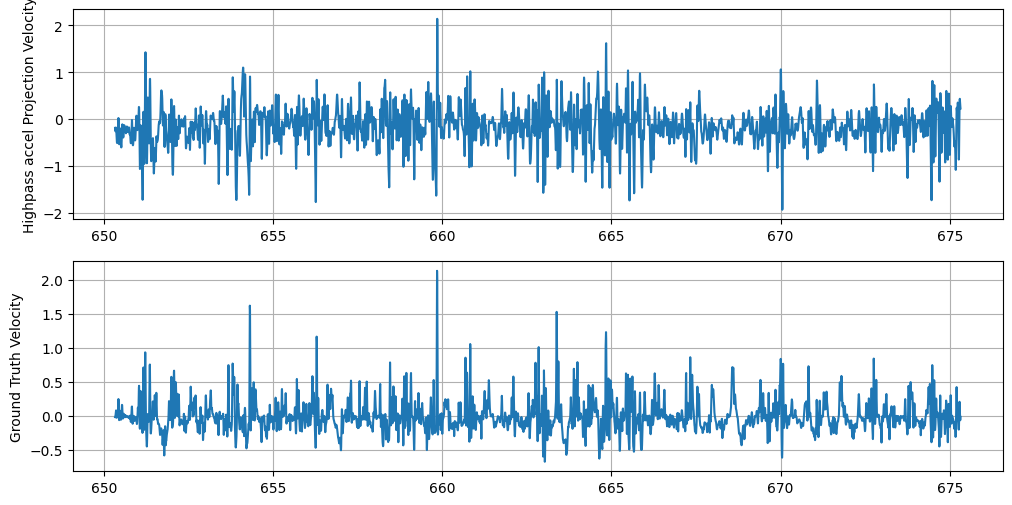

In [306]:
# Integrate accel to get velocity and plot
v = scipy.integrate.cumulative_trapezoid(a_hp_proj, t, initial=0)
v -= np.mean(v)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t[roi], v[roi])
plt.ylabel("Highpass accel Projection Velocity")
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(t[roi], v_gt[roi] / 1000)
plt.ylabel("Ground Truth Velocity")
plt.grid()

Mean V at ZV: 41.260408963795214


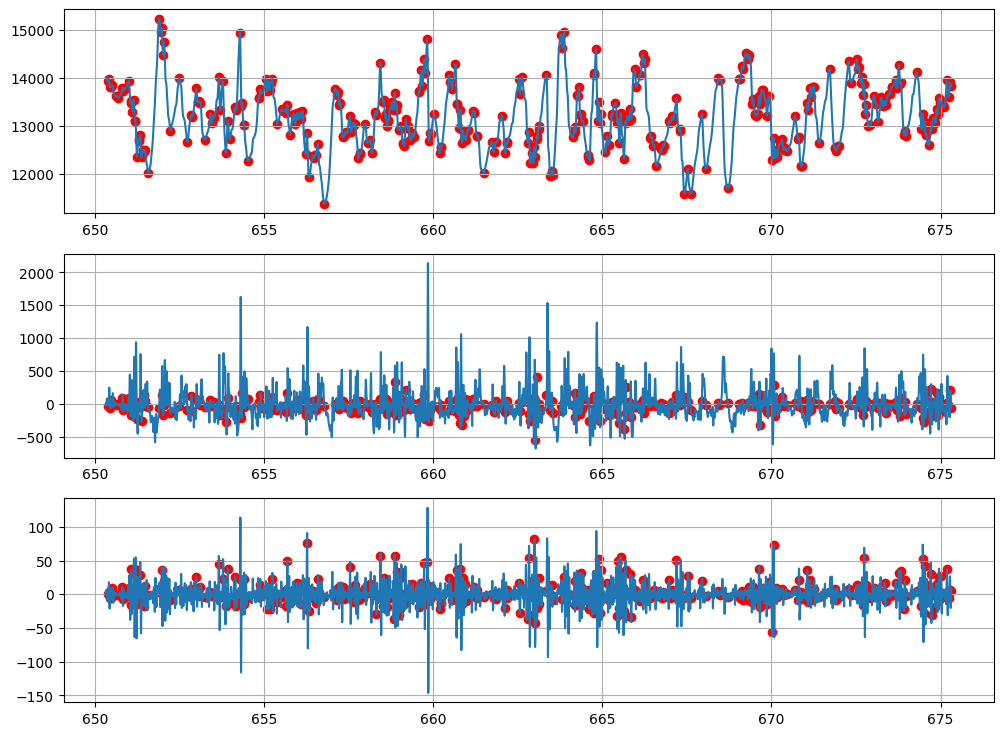

In [307]:
#mag_zv_points = ws["mag_zv_points"]

local_max_indices = (np.diff(np.sign(np.diff(b_proj))) < 0).nonzero()[0] + 1
local_min_indices = (np.diff(np.sign(np.diff(b_proj))) > 0).nonzero()[0] + 1
mag_zv_points = np.sort(np.concatenate((local_max_indices, local_min_indices)))
print("Mean V at ZV:", np.mean(np.abs(v_gt[mag_zv_points])))
plt.figure(figsize=(12, 9))
plt.subplot(3, 1, 1)
mag_zv_points_roi = (mag_zv_points > roi.start) & (mag_zv_points < roi.stop)
mag_zv_points_roi = mag_zv_points[mag_zv_points_roi] - roi.start
plt.plot(t[roi], b_proj[roi])
plt.scatter(t[roi][mag_zv_points_roi], b_proj[roi][mag_zv_points_roi], color="red")
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(t[roi], v_gt[roi])
plt.scatter(t[roi][mag_zv_points_roi], v_gt[roi][mag_zv_points_roi], color="red")
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(t[roi], a_gt[roi])
plt.scatter(t[roi][mag_zv_points_roi], a_gt[roi][mag_zv_points_roi], color="red")
plt.grid()

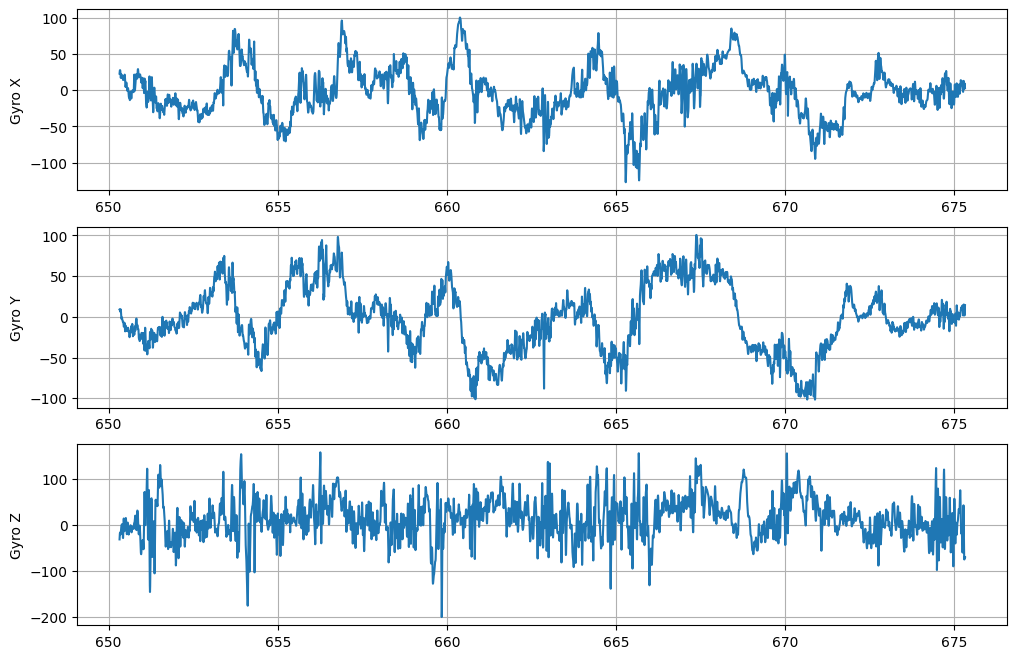

In [308]:
# Plot gyro
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(t[roi], gyro[:, 0][roi])
plt.ylabel("Gyro X")
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(t[roi], gyro[:, 1][roi])
plt.ylabel("Gyro Y")
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(t[roi], gyro[:, 2][roi])
plt.ylabel("Gyro Z")
plt.grid()

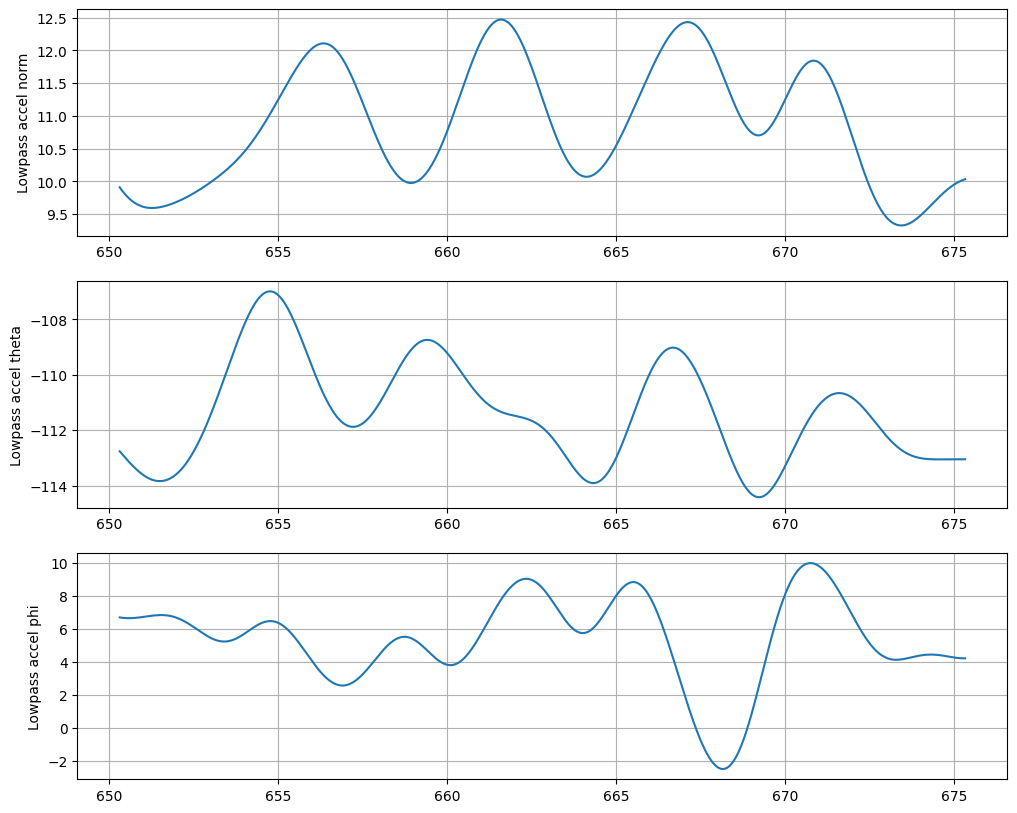

In [309]:
# Lowpass and plot accel
lp_fc_hz=0.25
sos_lp = butter(N=4, Wn=lp_fc_hz, btype="low", fs=200, output="sos")
a_lp = sosfiltfilt(sos_lp, a, axis=0)
a_lp_norm, a_lp_theta, a_lp_phi = get_polar(a_lp)

plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(t[roi], a_lp_norm[roi])
plt.ylabel("Lowpass accel norm")
plt.grid()
plt.subplot(3, 1, 2)
plt.plot(t[roi], a_lp_theta[roi])
plt.ylabel("Lowpass accel theta")
plt.grid()
plt.subplot(3, 1, 3)
plt.plot(t[roi], a_lp_phi[roi])
plt.ylabel("Lowpass accel phi")
plt.grid()

In [310]:
# Figure out gyro and accel projection axes
gyro_m = gyro[mask]
gyro_axis = np.mean(gyro_m[gyro_m[:, 2] > 0], axis=0)
gyro_axis /= np.linalg.norm(gyro_axis)

gyro_proj = (gyro @ gyro_axis)

gyro_a_corr = scipy.stats.pearsonr(gyro_proj[mask], v[mask])
print(f"Correlation between accel and gyro projections: {gyro_a_corr[0]:.3f} (p={gyro_a_corr[1]:.3e})")

gyro_a_vector = np.mean(gyro * v[:, np.newaxis], axis=0)
gyro_a_vector /= np.linalg.norm(gyro_a_vector)

a_gyro_vector = np.mean(a_hp * gyro_proj[:, np.newaxis], axis=0)
a_gyro_vector /= np.linalg.norm(a_gyro_vector)

print(f"Gyro-accel vector correlation: {gyro_a_vector}")
print(gyro_axis)
#gyro_proj = gyro @ gyro_a_vector
print(f"Accel-gyro vector correlation: {a_gyro_vector}")
print(accel_axis)
#a_proj = a @ a_gyro_vector


Correlation between accel and gyro projections: -0.650 (p=0.000e+00)
Gyro-accel vector correlation: [ 0.04860999  0.02158606 -0.99858455]
[-0.09073028 -0.03147936  0.99537785]
Accel-gyro vector correlation: [-0.60869448 -0.7625944   0.2189539 ]
[-0.29617601 -0.95383726  0.04974191]


In [311]:
# Correlate mag to accel and gyro
db_norm = np.gradient(b1_mag, t, edge_order=2)
db_corr_norm = np.gradient(b_corr_mag, t, edge_order=2)
#db_proj = np.gradient(b_proj, t, edge_order=2)
v_m = v[mask]
gyro_proj_m = gyro_proj[mask]

for series, name in zip([db_norm, db_corr_norm], ["Mag norm", "Mag corr norm"]):
    corr_a = scipy.stats.pearsonr(series[mask], v[mask])
    corr_g = scipy.stats.pearsonr(series[mask], gyro_proj[mask])
    spearman_a = scipy.stats.spearmanr(series[mask], v[mask])
    spearman_g = scipy.stats.spearmanr(series[mask], gyro_proj[mask])
    print(f"Correlation between {name} and accel projection velocity: {corr_a[0]:.3f} (Spearman: {spearman_a.correlation:.3f})")
    print(f"Correlation between {name} and gyro projection: {corr_g[0]:.3f} (Spearman: {spearman_g.correlation:.3f})")

Correlation between Mag norm and accel projection velocity: -0.462 (Spearman: -0.346)
Correlation between Mag norm and gyro projection: 0.400 (Spearman: 0.287)
Correlation between Mag corr norm and accel projection velocity: -0.474 (Spearman: -0.357)
Correlation between Mag corr norm and gyro projection: 0.422 (Spearman: 0.312)
